In [1]:
# Import the libraries we need for sentiment analysis
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the cleaned reviews we saved in Task 1
df = pd.read_csv('../data/raw/reviews.csv')

# Quick check
print(f"Total reviews loaded: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst review:")
print(df['review'][0])

Total reviews loaded: 1478
Columns: ['review', 'rating', 'date', 'bank', 'source']

First review:
🤙🏼🤙🏼


In [3]:
# Create the sentiment analyzer (our "judge")
analyzer = SentimentIntensityAnalyzer()

# Empty lists to store results
sentiment_labels = []
sentiment_scores = []

# Loop through every review and analyze it
for review in df['review']:
    # Get the sentiment scores
    scores = analyzer.polarity_scores(str(review))
    
    # The compound score is between -1 and 1
    compound = scores['compound']
    
    # Decide the label based on the compound score
    if compound >= 0.05:
        label = 'positive'
    elif compound <= -0.05:
        label = 'negative'
    else:
        label = 'neutral'
    
    sentiment_labels.append(label)
    sentiment_scores.append(compound)

# Add results to our dataframe
df['sentiment_label'] = sentiment_labels
df['sentiment_score'] = sentiment_scores

print("Sentiment analysis complete!")
print(f"\nSentiment distribution:")
print(df['sentiment_label'].value_counts())

Sentiment analysis complete!

Sentiment distribution:
sentiment_label
positive    904
neutral     365
negative    209
Name: count, dtype: int64


<Figure size 1000x600 with 0 Axes>

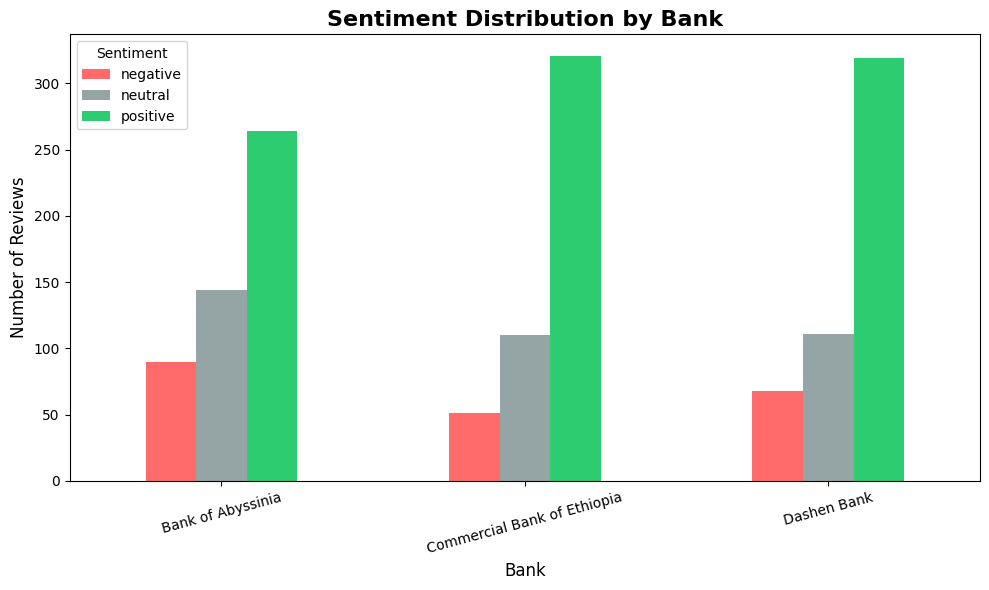

In [4]:
# Create a bar chart showing sentiment distribution per bank
plt.figure(figsize=(10, 6))

# Count sentiment labels per bank
sentiment_by_bank = df.groupby(['bank', 'sentiment_label']).size().unstack()

# Plot
sentiment_by_bank.plot(
    kind='bar',
    color=['#ff6b6b', '#95a5a6', '#2ecc71'],
    figsize=(10, 6)
)

plt.title('Sentiment Distribution by Bank', fontsize=16, fontweight='bold')
plt.xlabel('Bank', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Sentiment')
plt.tight_layout()

# Save the chart
plt.savefig('../data/raw/sentiment_chart.png', dpi=150)
plt.show()



In [5]:
# Save the reviews with sentiment labels to a new CSV
df.to_csv('../data/raw/reviews_with_sentiment.csv', index=False)

print("Saved reviews with sentiment labels!")
print(f"Total reviews: {len(df)}")
print(f"\nSentiment breakdown per bank:")
print(df.groupby(['bank', 'sentiment_label']).size().unstack())

Saved reviews with sentiment labels!
Total reviews: 1478

Sentiment breakdown per bank:
sentiment_label              negative  neutral  positive
bank                                                    
Bank of Abyssinia                  90      144       264
Commercial Bank of Ethiopia        51      110       321
Dashen Bank                        68      111       319


In [6]:
import sys
sys.path.append('..')

from src.themes import assign_theme, extract_keywords_per_bank
# Assign theme to every review
df['theme'] = df['review'].apply(assign_theme)

print("Theme distribution:")
print(df['theme'].value_counts())

Theme distribution:
theme
General                   1116
App Performance            108
Transfer & Payments         89
UI & Design                 60
Login & Authentication      48
Customer Service            42
Account Management          15
Name: count, dtype: int64


In [7]:
# Get top keywords per bank using TF-IDF
keywords_per_bank = extract_keywords_per_bank(df)

for bank, keywords in keywords_per_bank.items():
    print(f"\n{bank}:")
    print(f"Top keywords: {', '.join(keywords)}")


Commercial Bank of Ethiopia:
Top keywords: good, app, nice, best, ok, like, cbe, working, nice app, excellent

Bank of Abyssinia:
Top keywords: good, app, best, nice, boa, bank, working, work, fast, mobile

Dashen Bank:
Top keywords: good, app, nice, best, bank, dashen, easy, great, nice app, super


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=500
)

In [13]:
x = tfidf.fit_transform(df['review'])
feature_names = tfidf.get_feature_names_out()

In [16]:
scores = x.mean(axis=0).A1
tfidf_df = pd.DataFrame({
    'word': feature_names,
    'score': scores
})

In [17]:
top_words = tfidf_df.sort_values(
    by='score',
    ascending=False
).head(15)

top_words

,word,score
188,good,0.150406
29,app,0.097257
49,best,0.054162
274,nice,0.054127
45,bank,0.029454
435,use,0.019077
277,ok,0.018582
462,working,0.018085
160,fast,0.017850
241,like,0.016936


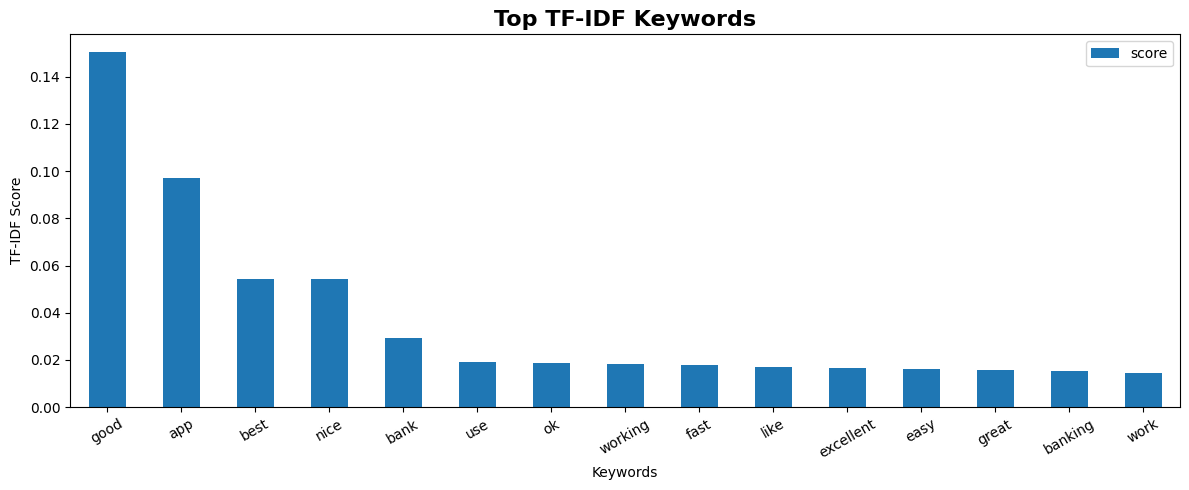

In [18]:
top_words.plot(
    x='word',
    y='score',
    kind='bar',
    figsize=(12,5)
)

plt.title('Top TF-IDF Keywords', fontsize=16, fontweight='bold')
plt.xlabel('Keywords')
plt.ylabel('TF-IDF Score')
plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig('../data/raw/tfidf_keywords.png', dpi=150)

plt.show()

<Figure size 1200x600 with 0 Axes>

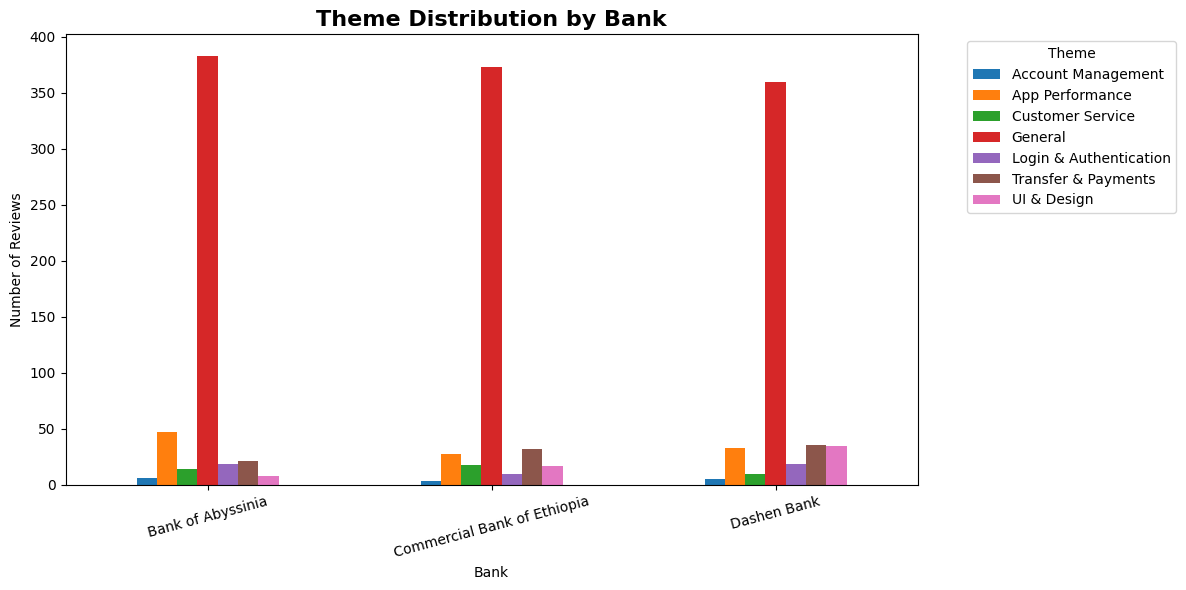

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
theme_by_bank = df.groupby(['bank', 'theme']).size().unstack(fill_value=0)
theme_by_bank.plot(kind='bar', figsize=(12, 6))
plt.title('Theme Distribution by Bank', fontsize=16, fontweight='bold')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=15)
plt.legend(title='Theme', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('../data/raw/theme_chart.png', dpi=150)
plt.show()


In [20]:
import spacy
nlp = spacy.load("en_core_web_sm")
def extract_entities(text):

    doc = nlp(str(text))

    entities = []

    for ent in doc.ents:
        entities.append((ent.text, ent.label_))

    return entities
df['entities'] = df['review'].apply(extract_entities)
df[['review', 'entities']].head()

,review,entities
0,🤙🏼🤙🏼,"[(🤙🏼🤙, ORG)]"
1,worst,[]
2,this app very full,[]
3,good apps,[]
4,ok,[]


In [21]:
organizations = []

for review in df['review']:

    doc = nlp(str(review))

    for ent in doc.ents:

        if ent.label_ == 'ORG':
            organizations.append(ent.text)
org_counts = pd.Series(organizations).value_counts().head(10)

org_counts            

CBE            14
UI             12
BOA            11
BoA            11
🙏               7
Dashen Bank     7
Bank            6
🇹               4
birr            4
BoA Mobile      3
Name: count, dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_23484\3116467969.py:10: UserWarning: Glyph 128591 (\N{PERSON WITH FOLDED HANDS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_23484\3116467969.py:10: UserWarning: Glyph 127481 (\N{REGIONAL INDICATOR SYMBOL LETTER T}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_23484\3116467969.py:12: UserWarning: Glyph 128591 (\N{PERSON WITH FOLDED HANDS}) missing from font(s) DejaVu Sans.
  plt.savefig('../data/raw/top_organizations.png', dpi=150)
C:\Users\HP\AppData\Local\Temp\ipykernel_23484\3116467969.py:12: UserWarning: Glyph 127481 (\N{REGIONAL INDICATOR SYMBOL LETTER T}) missing from font(s) DejaVu Sans.
  plt.savefig('../data/raw/top_organizations.png', dpi=150)
C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128591 (\N{PERSON WITH FOLDED HANDS}) missing from font(s) DejaVu Sans.
  fig.canvas

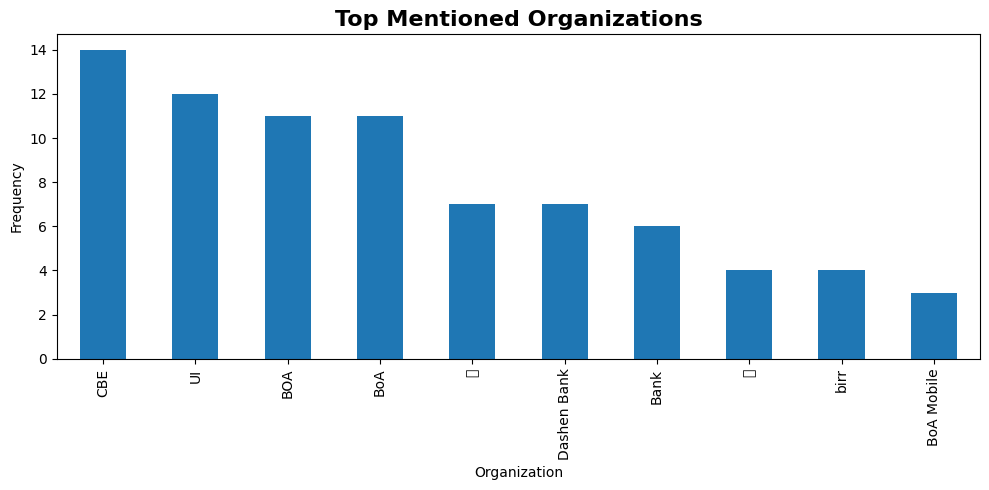

In [22]:
org_counts.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top Mentioned Organizations', fontsize=16, fontweight='bold')
plt.xlabel('Organization')
plt.ylabel('Frequency')

plt.tight_layout()

plt.savefig('../data/raw/top_organizations.png', dpi=150)

plt.show()

## Task 2 Findings

### Key Insights

- Transfer and payment issues were the most common customer concerns.
- Login and authentication problems appeared frequently across multiple banks.
- TF-IDF analysis identified important recurring fintech-related keywords.
- Different banks showed different customer complaint patterns.
- spaCy entity extraction identified financial organizations and entities mentioned in customer reviews.
- App performance and transaction reliability were major discussion themes.

In [28]:
df.columns

Index(['review', 'rating', 'date', 'bank', 'source', 'sentiment_label',
       'sentiment_score', 'theme', 'entities'],
      dtype='str')

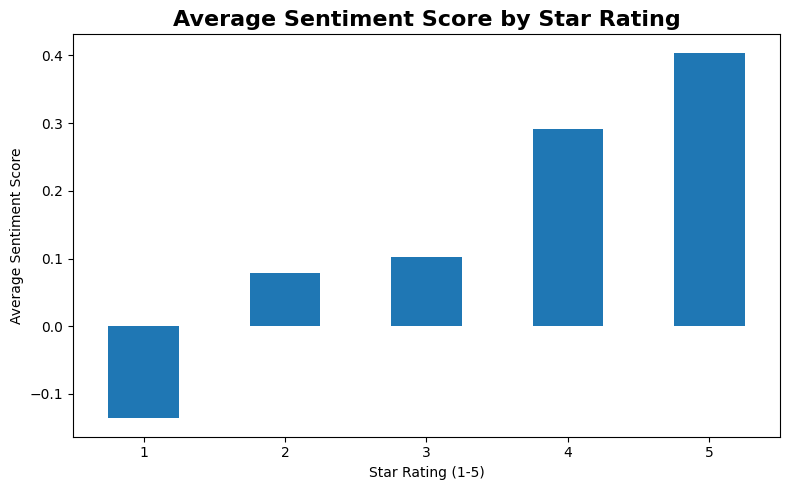

In [33]:
rating_sentiment = df.groupby('rating')['sentiment_score'].mean()

rating_sentiment.plot(
    kind='bar',
    figsize=(8, 5)
)
plt.title('Average Sentiment Score by Star Rating', fontsize=16, fontweight='bold')
plt.xlabel('Star Rating (1-5)')
plt.ylabel('Average Sentiment Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/raw/rating_sentiment.png', dpi=150)
plt.show()
